<a href="https://colab.research.google.com/github/vikubel/JavaAlgo/blob/master/Activity_3_2_autoencoders_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoders in Python




## Activity Overview

An autoencoder is an unsupervised machine learning algorithm that, for example, takes an image as input and tries to reconstruct it using a compressed latent representation (e.g., a latent representation requiring a fewer number of values than in the original image).

In this notebook, the famous MNIST dataset for images of written numerical digits is utilized. The autoencoder with a single hidden layer is first implemented. Then the results of this are compared with autoencoder with multiple layers.

This activity is designed to help apply the machine learning algorithms using the packages in `Python`. `Python` concepts, instructions, and starter code are embedded within this Jupyter Notebook to help in guiding the learners through the activity. Remember to run the code of each code cell prior to submitting the assignment. Upon completing the activity, we encourage you to compare your work against the solution file to perform a self-assessment.

## Index:

#### Week 3:  Autoencoders

- [Part 1](#part1) - Autoencoders
- [Part 2](#part2) - Setting up the Problem
- [Part 3](#part3) - Single-Layer Autoencoder
- [Part 4](#part4) - Multi-Layer Autoencoder

[Back to top](#Index:)

<a id='part1'></a>

# Autoencoders <a></a>

Autoencoders are unsupervised learning technique, because it doesn't require labels explicitly to train the model. The input required to an autoencoder is raw input data.

The  primary objective of an autoencoder is to take an input and reconstruct it using a reduced number of bits from the bottleneck, which is also referred to as the latent space. Notably, the image experiences maximal compression at this bottleneck. Achieving this compression in autoencoders involves training the network over a period of time. As the network learns, it endeavors to represent the input image optimally within the bottleneck.

Autoencoders work by using a dimensionality reduction technique. They project the data from a higher dimension to a lower dimension using a linear transformation and try to preserve the important features of the data while removing the non-essential parts.

The structure of the autoencoder has input layer, hidden layer and the output layer.

In the simple two-layer simplified autoencoder there is a input, hidden and output layer. In deep learning terminology, the input layer is never taken into account while counting the total number of layers in an architecture. In general, the total number of layers in an architecture only comprises the number of hidden layers and the ouput layer.

Of course, in typical practice, there are often a larger number of hidden layers in between the input and the output.

### Encoder vs. Decoder

The autoencoder has three parts:

- The **Encoder** compresses or downsamples the input into a fewer number of values. The space represented by these smaller number of values is often called the latent space or bottleneck.

- **The bottleneck** is also called the "maximum point of compression" since, at this point, the input is compressed the most. These compressed values that represent the original input are together called an “encoding” of the input.

- The **Decoder** tries to reconstruct the input using only the encoding of the input. When the decoder is able to reconstruct the input exactly as it was fed to the encoder, the encoder can then produce the best encodings for the input with which the decoder is able to reconstruct well!

## Convolutional Autoencoders in Python with Keras

A convolutional autoencoder is used in this case, because MNIST dataset is of images. This is a traditional autoencoder where each layer is a convolutional layer: The fully connected layers is replaced with convolutional layers.

[Back to top](#Index:)

<a id='part2'></a>

## Setting up the Problem <a></a>

The classic [`MNIST`](https://en.wikipedia.org/wiki/MNIST_database) dataset is a large database of handwritten digits commonly used for training various image processing systems. It contains images of handwritten digits 0 through 9  normalized to fit into a 28x28 pixel bounding box.

For this exercise, [`Keras`](https://keras.io) library is used. `Keras`  is an open-source software library that provides a Python interface for artificial neural networks. Keras acts as an interface for the `TensorFlow` library. [`TensorFlow`](https://www.tensorflow.org) is a free and open-source software library for machine learning. While it can be used across a range of tasks, it focuses on training and inference of deep neural networks.

The MNIST dataset is imported through `Keras`.

Run the code cell below to import some of the libraries which will be used in this exercise.

In [1]:
from keras.datasets import mnist
import numpy as np
from matplotlib import pyplot as plt

The MNIST dataset comprises of 70,000 28X28 pixels images of handwritten digits and 70,000 vectors containing information on which digit each one is. The image training data is scaled from [0, 255]  to allow for use of the sigmoid activation function.

Run the code cell below to import and scale the data.

In [2]:
(X_train, y_train), (X_test, y_train) = mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


To view data, the first image in the training dataset is plotted.

In the code cell below, fill in the ellipsis by passing the correct index to retrieve the desired image. Keep in mind that `Python` starts counting from 0!

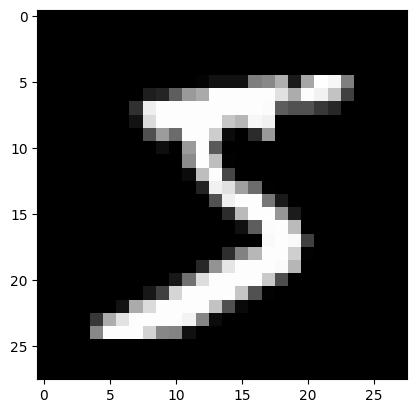

In [3]:
# Plot image data from x_train
#plt.imshow(X_train[...], cmap = "gray")

plt.imshow(X_train[0], cmap = "gray")
plt.show()

**Question**

What number is represented in the first image?

**CLICK ON THIS CELL TO TYPE YOUR ANSWER**

The image is that of number 5

[Back to top](#Index:)

<a id='part3'></a>

## Single-Layer Autoencoder <a></a>

The simple autoencoder with only one hidden layer is first implemented.

The image data comes in 28X28 pixel format. Out of the 70000 dataset, 60000 are used for training the model and 10000 samples are used for testing the model.


Run the code cell below to verify this.

In [4]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


The 'X' data is reshaped by flattening the image into a 28 *28 = 784 array.

In [5]:
X_train = X_train.reshape((len(X_train), np.prod(X_train.shape[1:])))
X_test = X_test.reshape((len(X_test), np.prod(X_test.shape[1:])))

This reshaping can be confirmed by printing the shape of the reshaped data.

Run the code below to print the shape of the reshaped data.

In [6]:
#print(...)
#print(...)

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


### Defining the Autoencoder

In the code cell below, assign to the variable `input_size` the dimension of the reshaped `X` data.

Next, the size of the bottleneck representation is set (the output of the encoder), as `latent_size` equal to 10.

In [7]:
#input_size = ...
input_size = 784

latent_size = 10

Finally, various parts of autoencoder are defined.

Run the code cell below to import the necessary libraries and modules.

In [8]:
from keras.models import Model
from keras.layers import Dense, Input

In the code cell below, the input to the model is defined with the appropriate shape.

Next, the way the input needs to be encoded is defined. This can be done with the help of the function `Dense` which takes, as argument, the size of the desired output and the type of activation - in this case, ReLu. The second set of brackets here indicates what we want to encode (the input image).

The output to be decoded is then defined. Here the function `Dense` is used. The sigmoid activation function is used in the output. The second set of brackets implies that the encoded image needs to be decoded. (i.e., that latent representation).

In [9]:
input_img = Input(shape=(input_size,)) # input

latent_rep = Dense(latent_size, activation='relu')(input_img) #encoding definition

output_img = Dense(input_size, activation='sigmoid')(latent_rep) #decoding definition

As the last step, the model is first initialized and then the model is run.

In the code cell below, the autoencoder is first defined, compiled and fitted to the model.

In the function compile, fill in the ellipssis by setting the argument `optimizer` equal to `"adam"`. Also the loss is set to `binary_crossentropy`.

Finally, set the number of `epochs` equal to 5.

Run the code cell below to start the model!

In [10]:
autoencoder = Model(input_img, output_img)

#autoencoder.compile(optimizer='...', loss='binary_crossentropy')

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


#autoencoder.fit(X_train, X_train, epochs=...)

autoencoder.fit(X_train, X_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2711
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1663
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.1607
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1579
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1561


### Visualizing our Results



In the code cell below, we have defined an auxiliary function to visualize our results. The first part of the function plots the original data from the dataset, and the second one displays the autoencoded images.

Run the code cell below to define our plotting function.

In [11]:
def plot_autoencoder_outputs(autoencoder, n, dims):
    decoded_imgs = autoencoder.predict(X_test)

    # number of example digits to show
    n = 5
    plt.figure(figsize=(10, 4.5))
    for i in range(n):
        # plot original image
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(X_test[i].reshape(*dims))
        plt.gray()
        if i == n/2:
            ax.set_title('Original Images')

        # plot reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(*dims))
        plt.gray()
        if i == n/2:
            ax.set_title('Reconstructed Images')
    plt.show()

Finally, run the code cell below to visualize the results.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


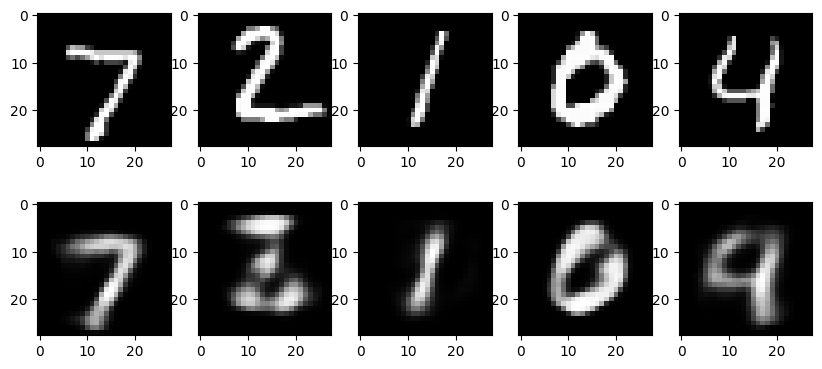

In [12]:
plot_autoencoder_outputs(autoencoder, 5, (28, 28))

The results are not great; for example, the reconstructed "2" looks somewhat like a "3", and the reconstructred "4" looks somewhat like a "9".

**Question**

What do you think would happen to the results if you increased the `latent_size` above, say to 32? Feel free to experiment with the code above.

**CLICK ON THIS CELL TO TYPE YOUR ANSWER**




The results should get better, as we compress the input to a larger middle latent reprentation than before.

[Back to top](#Index:)

<a id='part4'></a>

# Multi-Layer Autoencoder <a></a>
    
In the final part of this activity, we will redefine our encoder to have multiple layers. This is usually what happens in real life.

In the code cell below, the input and output sizes are defined as above. Note that in addition, the size of the hidden layers in each of the multilayer encoder and decoder,is also defined as `hidden_size`.

A smaller `latent_size`, is used to see how the more complex encoder and decoder might work, even with the smaller sized bottleneck.

In [13]:
input_size = 784
hidden_size = 128
latent_size = 10

The function `Dense` is used to define the various layers. Note that we now have multiple (2) hidden layers that use a ReLU function as activation.

In [14]:
input_img = Input(shape=(input_size,))
hidden_1 = Dense(hidden_size, activation='relu')(input_img)
latent_rep = Dense(latent_size, activation='relu')(hidden_1)
hidden_2 = Dense(hidden_size, activation='relu')(latent_rep)
output_img = Dense(input_size, activation='sigmoid')(hidden_2)

As a last step, the autoencoder is defined, compiled and fitted to the model.

In the function `compile`, fill in the ellipsis by setting the argument `optimize` equal to `"adam"`.

Finally, set the number of `epochs` equal to 5, the same as with the single layer autoencoder.

Run the code cell below to start your model!

In [15]:
autoencoder = Model(input_img, output_img)

#autoencoder.compile(optimizer='...', loss='binary_crossentropy')

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
#autoencoder.fit(x_train, x_train, epochs=...)

autoencoder.fit(X_train, X_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.2112
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.1330
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.1251
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1218
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.1193


Finally, the auxiliary plotting function is used to view the different plots.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


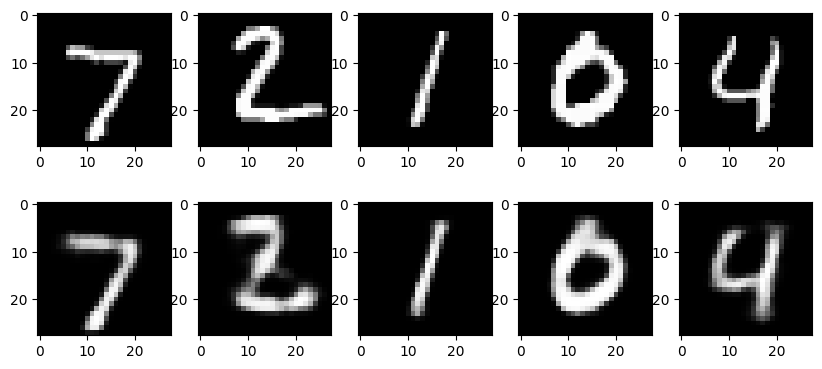

In [16]:
plot_autoencoder_outputs(autoencoder, 5, (28, 28))

**Question**

What difference do you notice compared to the output of the single-layer encoder? Can you justify them?



**CLICK ON THIS CELL TO TYPE YOUR ANSWER**

(Correct answer, not to be shown to the students):

Better results are obtained using multiple layers. Multiple layers also enables a better encoding/decoding to and from the latent representation.  (even with the latent representation size being kept the same).